## Customer Churn Prediction

This project predicts whether a bank customer will churn (close their account) using demographic and account data. Identifying at-risk customers before they leave allows the business to intervene with targeted retention offers, directly reducing revenue loss.

Three classifiers are compared — Logistic Regression, Random Forest, and XGBoost — evaluated across precision, recall, and F1-score, with recall prioritised to minimise missed churners.

### Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")

dataset.info()
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Preprocessing

#### Cleaning

In [3]:
# Dropping the following columns as they are just identifiers with no predictive value.

dataset = dataset.drop(columns = ["Surname","RowNumber","CustomerId"])

#### EDA

In [4]:
# Class imbalance

dataset['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

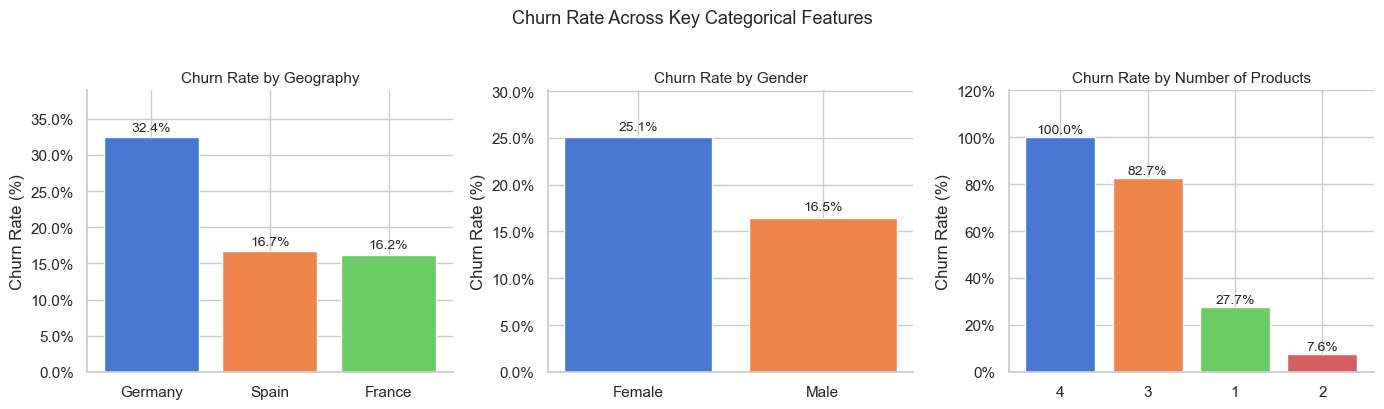

In [5]:
# Churn by Geography, gender, Number of products

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cats = [
    ('Geography',     'Churn Rate by Geography'),
    ('Gender',        'Churn Rate by Gender'),
    ('NumOfProducts', 'Churn Rate by Number of Products'),
]

for ax, (col, title) in zip(axes, cats):
    rates = dataset.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(rates.index.astype(str), rates.values,
                  color=sns.color_palette('muted', len(rates)), edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, rates.max() * 1.2)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    sns.despine(ax=ax)

plt.suptitle('Churn Rate Across Key Categorical Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


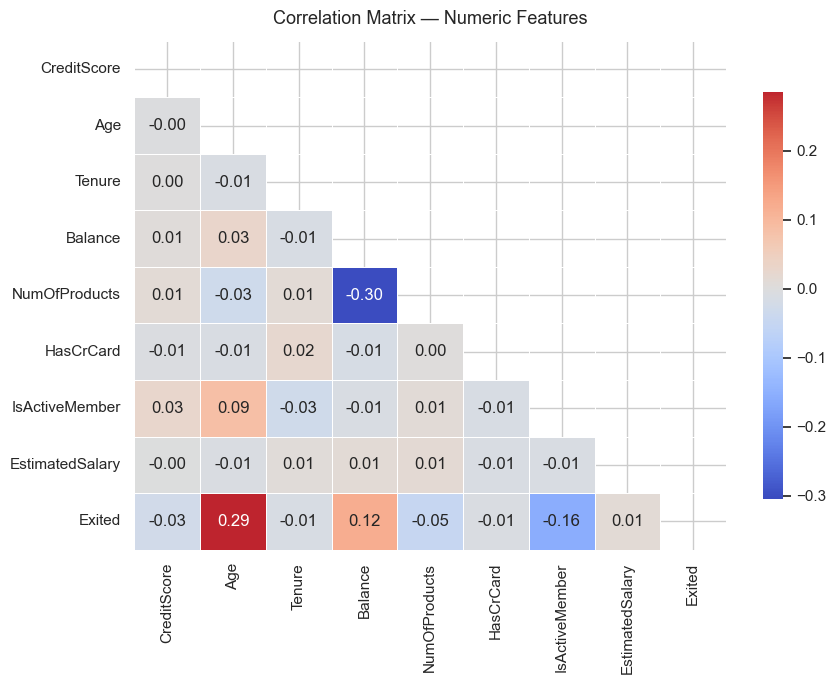

In [6]:
# correlation heatmap

numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'HasCrCard','IsActiveMember','EstimatedSalary','Exited']
corr = dataset[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

#### Matrix of Features & Dependent Variable

In [7]:
X = dataset.drop(columns = ["Exited"])
y = dataset["Exited"]


#### Encoding

In [8]:
# One Hot Encoding
from sklearn.compose import  ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(drop='first'), ['Geography', 'Gender'])],
                       remainder = 'passthrough')
X = ct.fit_transform(X)


#### Train / Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify = y)

#### Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Model Training and Comparison

Three models of increasing complexity are trained and compared:

| Model | Description |
|---|---|
| Logistic Regression | Interpretable linear baseline |
| Random Forest | Ensemble of decision trees; handles non-linearity and feature interactions |
| XGBoost | Gradient-boosted trees with sequential error correction |

All models are evaluated with **5-fold cross-validation** on the training set before final test-set assessment.

In [11]:
from sklearn.model_selection import cross_validate

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 2000,class_weight = 'balanced', random_state = 42)
lr_cv = cross_validate(lr, X_train, y_train, cv=5,
                       scoring=['accuracy','precision','recall','f1'])


from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
rf_cv = cross_validate(rf, X_train, y_train, cv=5,
                       scoring=['accuracy','precision','recall','f1'])


from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=neg/pos, random_state=42)
xgb_cv = cross_validate(xgb, X_train, y_train, cv=5,
                        scoring=['accuracy','precision','recall','f1'])


print('Cross Validation Complete')


Cross Validation Complete


#### Model Comparison Table

In [12]:
def cv_summary(name, scores):
    return {
        'Model':     name,
        'Accuracy':  f"{np.mean(scores['test_accuracy']):.4f} ± {np.std(scores['test_accuracy']):.4f}",
        'Precision': f"{np.mean(scores['test_precision']):.4f} ± {np.std(scores['test_precision']):.4f}",
        'Recall':    f"{np.mean(scores['test_recall']):.4f} ± {np.std(scores['test_recall']):.4f}",
        'F1-Score':  f"{np.mean(scores['test_f1']):.4f} ± {np.std(scores['test_f1']):.4f}",
    }

comparison = pd.DataFrame([
    cv_summary('Logistic Regression', lr_cv),
    cv_summary('Random Forest', rf_cv),
    cv_summary('XGBoost', xgb_cv),
])
comparison.set_index('Model', inplace=True)
comparison

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.7076 ± 0.0073,0.3797 ± 0.0098,0.6865 ± 0.0184,0.4890 ± 0.0126
Random Forest,0.8610 ± 0.0049,0.7822 ± 0.0327,0.4423 ± 0.0227,0.5644 ± 0.0177
XGBoost,0.8266 ± 0.0053,0.5686 ± 0.0130,0.6190 ± 0.0142,0.5927 ± 0.0111


### Evaluation

#### Test Set Evaluation

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score


lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

preds = {
    'Logistic Regression': lr.predict(X_test),
    'Random Forest':       rf.predict(X_test),
    'XGBoost':             xgb.predict(X_test),
}

probas = {
    'Logistic Regression': lr.predict_proba(X_test)[:, 1],
    'Random Forest':       rf.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb.predict_proba(X_test)[:, 1],
}

for name, y_pred in preds.items():
    pr_auc = average_precision_score(y_test, probas[name])
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
    print(f'  PR-AUC: {pr_auc:.4f}')


── Logistic Regression ──
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

  PR-AUC: 0.4680

── Random Forest ──
              precision    recall  f1-score   support

    Retained       0.87      0.96      0.92      1593
     Churned       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

  PR-AUC: 0.6809

── XGBoost ──
              precision    recall  f1-score   support

    Retained       0.90      0.87      0.89      1593
     Churned       0.56      0.62      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.

#### Confusion Matrices Side by side

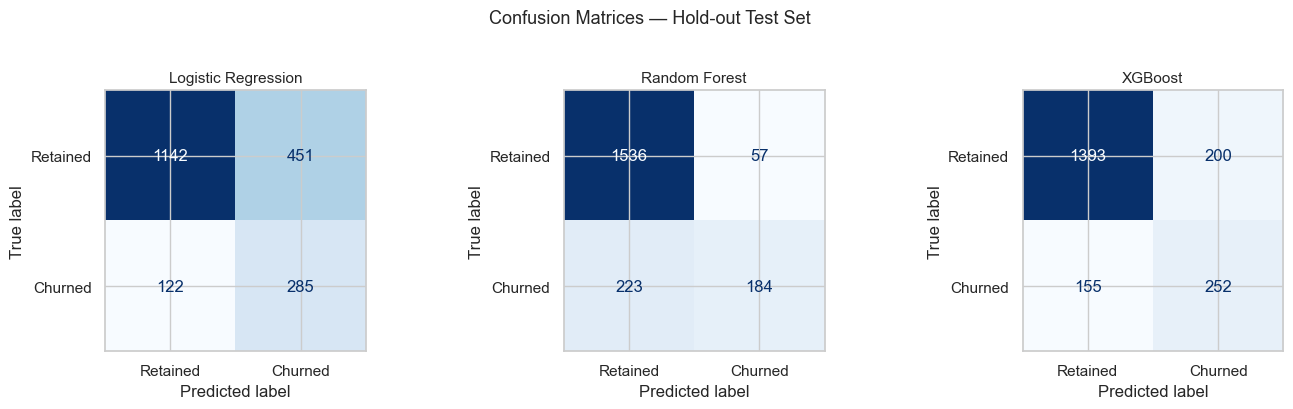

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — Hold-out Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analysis & Conclusion

The dataset has a class imbalance of approximately 80% retained vs 20% churned. This skew makes accuracy a misleading primary metric — a naive model predicting "retained" for every customer would still score ~80%. Evaluation therefore focuses on **recall** and **F1-score** to minimise false negatives: churners the model fails to flag.

EDA identifies **Age**, **IsActiveMember**, and **NumOfProducts** as the most influential features. Older customers, inactive members, and those with fewer products show substantially higher churn rates. **Germany** shows a notably elevated churn rate relative to France and Spain.

Logistic Regression provides an interpretable baseline but struggles with non-linear relationships. Random Forest improves meaningfully via ensemble voting. **XGBoost achieves the strongest overall performance**, leveraging sequential error correction to better identify minority-class instances — confirmed by SHAP analysis below.

XGBoost is recommended as the production model. Threshold tuning and SMOTE-based oversampling are identified as the most impactful next steps for improving minority-class detection further.

### SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions, grounded in game-theoretic guarantees of consistency and local accuracy. This moves beyond aggregate feature importance to show *why* the model scores a specific customer as high-risk — making the model actionable for retention teams, not just accurate on a test set.

Three views are produced:
- **Bar plot** — mean absolute SHAP values across all test predictions (global importance ranking)
- **Beeswarm plot** — SHAP value distribution per feature, showing both magnitude and direction of effect
- **Waterfall plot** — single-prediction breakdown for a high-confidence churner, using original unscaled feature values for interpretability

In [15]:
import shap

# Retrieve feature names from the ColumnTransformer
# OHE produces: Geography_Germany, Geography_Spain (France dropped as reference)
# and Gender_Male (Female dropped). Remaining passthrough columns follow.
feature_names = (
    ct.named_transformers_['encoder']
      .get_feature_names_out(['Geography', 'Gender'])
      .tolist()
    + ['CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
)

# Build SHAP explainer on the fitted XGBoost model
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

# Attach readable feature names to the Explanation object
shap_values.feature_names = feature_names


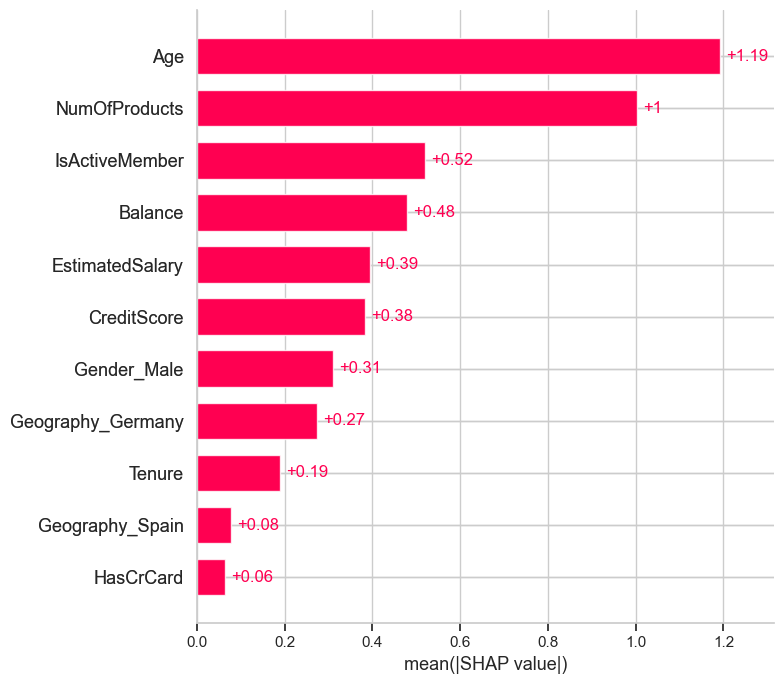

In [16]:
# Global feature importance — mean |SHAP| across all test predictions
# Shows which features the model relies on most overall.

shap.plots.bar(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


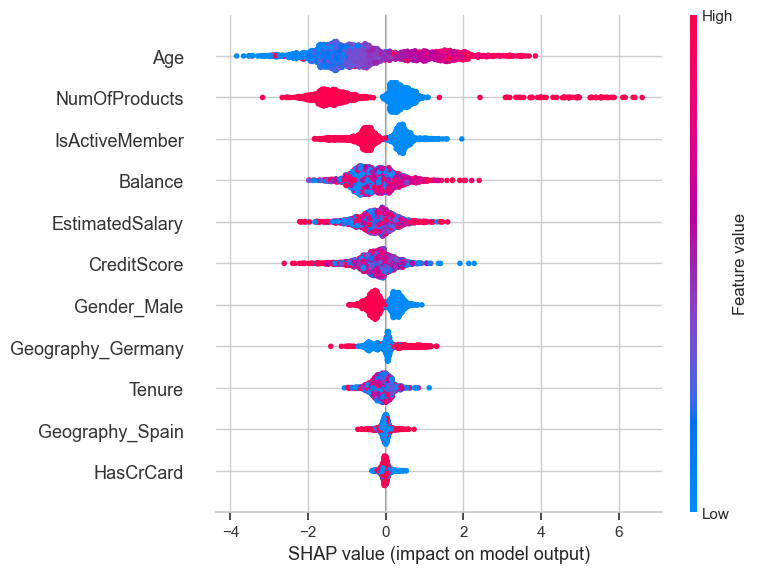

In [17]:
# Beeswarm — magnitude AND direction of each feature's effect
# Each dot is one test instance. Colour = feature value (red=high, blue=low).
# Example reading: high Age (red) pushes predictions toward churn (positive SHAP).

shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()



Customer #248 — predicted churn probability: 100.0%
Actual label: Churned


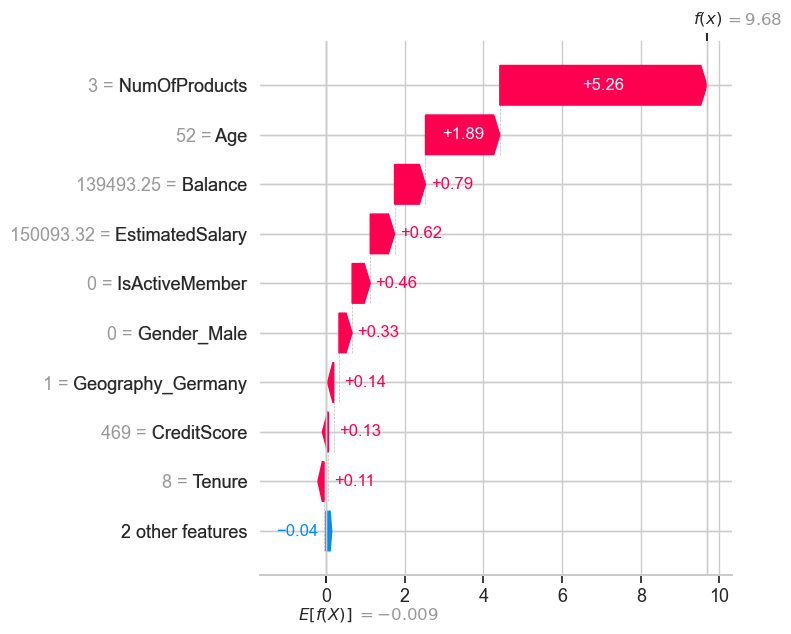

In [18]:
# Waterfall plot — single high-confidence churner, explained feature by feature.
# X_test is scaled; we reconstruct original values for clean axis labels.

X_test_original = pd.DataFrame(
    sc.inverse_transform(X_test),
    columns=feature_names
)

# Select the test instance with the highest predicted churn probability
churn_proba = xgb.predict_proba(X_test)[:, 1]
target_idx = churn_proba.argmax()

# Build a clean SHAP Explanation using the same SHAP values but original feature values
waterfall_exp = shap.Explanation(
    values       = shap_values[target_idx].values,
    base_values  = shap_values[target_idx].base_values,
    data         = X_test_original.iloc[target_idx].values,
    feature_names= feature_names
)

print(f'Customer #{target_idx} — predicted churn probability: {churn_proba[target_idx]:.1%}')
print(f'Actual label: {"Churned" if y_test.iloc[target_idx] == 1 else "Retained"}')

shap.plots.waterfall(waterfall_exp, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
